# Download and prepare `PA` (2005-2025)

**notebook version**: `2` (20 Jul 2026)

## ℹ️ About this notebook

Downloads screened atmospheric pressure `PA` from the InfluxDB database, **harmonises the units of
the two data sources**, merges them into one continuous series, applies the 2012 corrections and
stores the result to the external data folder.

Same structure as notebooks `01` (`SW_IN`), `02` (`TA`) and `03` (`PPFD_IN`), with three deliberate
differences, each explained where it happens:

1. **The two sources are stored in different units** (`kPa` and `Pa`). They are harmonised to `kPa`
   *before* anything is merged, plotted or summarised. This is the main thing this notebook does
   that the others do not.
2. **No gap-filling.** The measured record is 99.15% complete, so the series is exported as
   measured. See "No gap-filling here" below.
3. **The record starts 2005-09-02**, when the sensor starts. There is no `PA` for 2004 and most of
   2005, and none is invented, so unlike `01`-`03` the index does not begin at 2004-01-01.

**Output column:**

- `PA_T1_47_1` — atmospheric pressure in **kPa**, measured, corrected, with genuine gaps left as
  `NaN`

There is **no `FLAG_..._ISFILLED` column**: nothing is filled, so every non-null record is a
measurement and every gap is a real gap. This differs from `01`-`03`, which are gap-filled products
and carry a flag.

Downloading uses diive's in-house InfluxDB engine `InfluxIO`. It needs `influxdb-client`, which
a plain `uv sync` installs here via the `diive[db]` extra.

***

## 📇 Data sources

- `PA_T1_47_1` — the exported variable. Tower 1, 47 m. `mst` (2005-2021) and `diive` (2022-2025).
  The two do not overlap.
- `PA_NABEL_H1_2_1` — a second barometer at the hut, 2 m, **2004-2018**, on the **NABEL**
  acquisition system. Used here as a diagnostic reference for the 2012 corrections; *not* exported
  and *not* a driver, because nothing is gap-filled. Its value is that it is independent of the
  tower logger, which is what is needed to judge a tower-logger fault. It ends in 2018, so on its
  own it cannot check the later years.
- `PA_LAE_MS` — MeteoSwiss Lägern station pressure (2.5 km, 845 m), **2004-2025**. A second
  independent diagnostic reference, read from the reference product (see `REFPATH`), that spans the
  whole record and so validates the years after NABEL stops. Stored in `hPa`; divided by 10 to
  `kPa`. Diagnostic only, never exported.
- `PA_H1_0_1` (2017-2019, kPa) also exists in the database but is not used: it is short, and it
  overlaps a period where `PA_T1_47_1` is already essentially complete.

Legend:
- NABEL ... Data from [NABEL](https://www.bafu.admin.ch/bafu/en/home/topics/air/luftbelastung/national-air-pollution-monitoring-network--nabel-.html), meteoscreening with [diive](https://github.com/holukas/diive)
- MeteoSwiss ... [MeteoSwiss](https://www.meteoswiss.admin.ch/) open data, station Lägern (LAE); produced by `10_REFERENCE`
- mst ... Data from ETH, meteoscreening with the now deprecated MeteoscreeningTool
- diive ... Data from ETH, meteoscreening with diive

## ⚠️ The unit break, and why it is handled first

The two sources of `PA_T1_47_1` are stored in **different units**, differing by exactly a factor
of 1000, with a clean break at the 2021/2022 boundary and no overlap:

| source | n | period | median as stored | unit |
|---|---|---|---|---|
| `meteoscreening_mst` | 283,395 | 2005-09-02 -> 2021-12-31 | 93.33 | kPa |
| `meteoscreening_diive` | 70,012 | 2022-01-01 -> 2025-12-31 | 93,228.45 | Pa |

(The *medians* above are in the ratio 998.9 rather than 1000.0 because they cover different
years and pressure varies; it is the **unit** that differs by exactly 1000.)

Merging these two as they are would produce a series that jumps by three orders of magnitude in the
middle. Every heatmap, every `describe()`, every mean and standard deviation computed across the
break would be meaningless, and — worst of all — the result would still *look* like a number.

So the harmonisation runs **before the merge**, and it does not trust the calendar:

- The unit is decided **per source, from the magnitude of the data**, not from the split date.
  Surface pressure at CH-LAE (~690 m a.s.l.) is about 93 kPa = 930 hPa = 93,000 Pa, and those three
  candidates are three orders of magnitude apart, so the median identifies the unit unambiguously.
- The magnitude verdict is **cross-checked against the unit tag the database itself carries**
  (`units` is stored per series: `kPa` for `mst`, `Pa` for `diive`, `hPa` for NABEL). If the two
  disagree, the notebook **raises** rather than guessing.
- After conversion, the **full range** of every source must lie inside the plausible band, not just
  the median. A source that does not match raises.

A silent factor-1000 error is the single worst outcome this notebook could produce, so every path
through the helper either converts correctly or stops.

**Output unit is `kPa`**, which is the FLUXNET convention, what `diive`'s FLUXNET formatter documents
(`PA (kPa)`), what notebook `x-99` already declares when writing `Pa_1_1_1` for EddyPro, and what the
existing `11_METEO6` product carries.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts the UTC timestamp by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local
time** (UTC + offset) and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)`
then converts to `TIMESTAMP_MID`, which is what the rest of this notebook works with.

`START` and `STOP` are interpreted in the same timezone as `TIMEZONE_OFFSET_TO_UTC_HOURS`.

***

## ⚙️ Settings

### Data settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

TARGET = "PA_T1_47_1"           # exported variable, tower 47 m
REFERENCE = "PA_NABEL_H1_2_1"   # hut barometer, diagnostics only, never exported

# PA measurements start 2005-09-02. The exported index starts there rather than at 2004-01-01:
# there is no pressure before it and none is reconstructed, so a 2004 index would begin with
# 20 months of nothing.
RECORD_START = '2005-09-02'
RECORD_END = '2025-12-31'

# Output: data files live in the external (untracked) data folder, with the same numeric prefix
# as this notebook. The name says neither GAPFILLED nor 2004, because it is neither.
OUTNAME = "05_METEO_PA_2005-2025"
OUTPATH = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"

# Reference: MeteoSwiss Lägern station pressure (QFE), 2.5 km from the tower at 845 m. An
# independent diagnostic reference that spans the whole 2004-2025 record, so it can check the
# years after the NABEL barometer stops in 2018. Diagnostic only, never exported. Produced by
# 10_REFERENCE/MeteoSwiss_LAE_2004-2025.ipynb; addressed by path, so a move breaks this read.
REFPATH = (r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
           r"\workflow\10_METEO\10_REFERENCE\MeteoSwiss_LAE_30MIN_2004-2025.parquet")
REFCOL = "PA_LAE_MS"  # hPa in the reference file; divided by 10 to kPa where it is used


### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme('notebook')

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-21 00:55:56
diive version: v0.91.0


### 🧭 Unit harmonisation helper

`harmonise_to_kpa()` is the guard described above. It refuses to convert anything it cannot identify
with certainty, and it never looks at the date.

`PA_PLAUSIBLE_KPA` is deliberately generous (85-100 kPa). Recorded extremes at this site are
89.4-95.5 kPa, and the band only has to be tight enough to separate `kPa` from `hPa` from `Pa`,
which are 10x and 1000x apart.

In [3]:
# Plausible surface pressure at CH-LAE (~690 m a.s.l.). Wide enough to accept any real weather,
# far too narrow to accept a value that is off by a factor of 10 or 1000.
PA_PLAUSIBLE_KPA = (85.0, 100.0)

UNIT_FACTORS_TO_KPA = {'kPa': 1.0, 'hPa': 0.1, 'Pa': 0.001}


def harmonise_to_kpa(series: pd.Series, source: str, declared_unit: str | None = None) -> pd.Series:
    """Convert a pressure series to kPa, identifying its unit from the data itself.

    The unit is decided by magnitude, NOT by date: the median is multiplied by each candidate
    factor and exactly one result must land inside `PA_PLAUSIBLE_KPA`. `declared_unit` is the
    unit tag stored alongside the series in the database; when given it must agree with the
    magnitude verdict.

    Raises ValueError if the unit is ambiguous, if the declared and detected units disagree, or
    if any converted value falls outside the plausible band. Silently returning a series that is
    off by a factor of 1000 is the one outcome that must never happen.
    """
    s = series.dropna()
    if s.empty:
        raise ValueError(f"{source}: no data, cannot determine unit.")

    lo, hi = PA_PLAUSIBLE_KPA
    median = float(s.median())
    matches = [u for u, f in UNIT_FACTORS_TO_KPA.items() if lo <= median * f <= hi]
    if len(matches) != 1:
        raise ValueError(
            f"{source}: median {median:,.2f} is consistent with {matches or 'no'} unit(s), "
            f"expected exactly one. Surface pressure here is ~93 kPa / ~930 hPa / ~93,000 Pa.")
    detected = matches[0]

    if declared_unit is not None and declared_unit != detected:
        raise ValueError(
            f"{source}: the database declares '{declared_unit}' but the magnitude says "
            f"'{detected}' (median {median:,.2f}). Refusing to guess - check the source.")

    factor = UNIT_FACTORS_TO_KPA[detected]
    out = series * factor

    converted = out.dropna()
    if not (lo <= converted.min() and converted.max() <= hi):
        raise ValueError(
            f"{source}: after converting {detected} -> kPa the range is "
            f"{converted.min():.2f}..{converted.max():.2f} kPa, outside the plausible "
            f"{lo}..{hi} kPa. Not exporting this.")

    print(f"  {source:<26} {detected:>3} -> kPa (x{factor:g})   n={len(converted):>7,}   "
          f"median {float(converted.median()):7.3f}   "
          f"range {converted.min():.2f}..{converted.max():.2f}")
    return out

### 🔌 Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

Three series are downloaded: the target from both of its data versions, and the NABEL reference.

The unit tag each series carries in the database is read back here and passed to
`harmonise_to_kpa()` as `declared_unit`, so the database's own claim and the data's magnitude have
to agree.

In [5]:
%%time

BUCKET = 'ch-lae_processed'
MEASUREMENTS = ['PA']


def download(fields, start, stop, data_version):
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=MEASUREMENTS, fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)
    return TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()


mst_pa = download([TARGET], '2004-01-01 00:00:01', '2022-01-01 00:00:01', 'meteoscreening_mst')
diive_pa = download([TARGET, REFERENCE], '2004-01-01 00:00:01', '2026-01-01 00:00:01',
                    'meteoscreening_diive')

print(f"mst   {TARGET}: {mst_pa[TARGET].notna().sum():,} records")
print(f"diive {TARGET}: {diive_pa[TARGET].notna().sum():,} records")
print(f"diive {REFERENCE}: {diive_pa[REFERENCE].notna().sum():,} records")

> DOWNLOADING from bucket ch-lae_processed: variables ['PA_T1_47_1'] from measurements ['PA'], 
data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2022-01-01 00:00:01 (timezone 
offset to UTC 1)

> Downloaded data for 1 variables:

> DOWNLOADING from bucket ch-lae_processed: variables ['PA_T1_47_1', 'PA_NABEL_H1_2_1'] from 
measurements ['PA'], data version ['meteoscreening_diive'], between 2004-01-01 00:00:01 and 
2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 2 variables:

mst   PA_T1_47_1: 283,395 records
diive PA_T1_47_1: 70,012 records
diive PA_NABEL_H1_2_1: 262,305 records
CPU times: total: 10.8 s
Wall time: 15.5 s


In [6]:
# The unit each series is stored with, straight from the database tags.
def declared_unit(field, data_version):
    tags = dbc.show_field_overview(bucket=BUCKET, measurement='PA', field=field,
                                   data_version=data_version, verbose=False)['tags']
    units = tags['units']
    if len(units) != 1:
        raise ValueError(f"{field} ({data_version}): expected one unit tag, found {units}.")
    return units[0]


UNIT_MST = declared_unit(TARGET, 'meteoscreening_mst')
UNIT_DIIVE = declared_unit(TARGET, 'meteoscreening_diive')
UNIT_NABEL = declared_unit(REFERENCE, 'meteoscreening_diive')
print(f"database unit tags -> mst: {UNIT_MST} | diive: {UNIT_DIIVE} | NABEL: {UNIT_NABEL}")

database unit tags -> mst: kPa | diive: Pa | NABEL: hPa


### Before harmonisation

This is the only place the raw, unharmonised values are shown, to document the break. Note that the
two medians differ by a factor of 1000 while describing the same physical quantity at the same
place.

In [7]:
_raw = pd.DataFrame({
    'n': [mst_pa[TARGET].notna().sum(), diive_pa[TARGET].notna().sum(),
          diive_pa[REFERENCE].notna().sum()],
    'first': [mst_pa[TARGET].first_valid_index(), diive_pa[TARGET].first_valid_index(),
              diive_pa[REFERENCE].first_valid_index()],
    'last': [mst_pa[TARGET].last_valid_index(), diive_pa[TARGET].last_valid_index(),
             diive_pa[REFERENCE].last_valid_index()],
    'median_as_stored': [mst_pa[TARGET].median(), diive_pa[TARGET].median(),
                         diive_pa[REFERENCE].median()],
    'unit_tag': [UNIT_MST, UNIT_DIIVE, UNIT_NABEL],
}, index=[f'{TARGET} (mst)', f'{TARGET} (diive)', f'{REFERENCE} (diive)'])
display(_raw)
print(f"ratio of the two {TARGET} medians: "
      f"{float(diive_pa[TARGET].median() / mst_pa[TARGET].median()):,.1f}")

,n,first,last,median_as_stored,unit_tag
PA_T1_47_1 (mst),283395,2005-09-02 10:15:00,2021-12-31 23:45:00,93.326965,kPa
PA_T1_47_1 (diive),70012,2022-01-01 00:15:00,2025-12-31 23:45:00,93228.454000,Pa
PA_NABEL_H1_2_1 (diive),262305,2004-01-01 00:15:00,2018-12-31 23:45:00,937.350000,hPa


ratio of the two PA_T1_47_1 medians: 998.9


***

## 🧮 Unit harmonisation

Every series is converted to `kPa` here, **before** the merge and before any plot or statistic.

In [8]:
print("Harmonising to kPa (unit detected from magnitude, cross-checked against the database tag):")
pa_mst = harmonise_to_kpa(mst_pa[TARGET], f'{TARGET} (mst)', declared_unit=UNIT_MST)
pa_diive = harmonise_to_kpa(diive_pa[TARGET], f'{TARGET} (diive)', declared_unit=UNIT_DIIVE)
pa_nabel = harmonise_to_kpa(diive_pa[REFERENCE], f'{REFERENCE}', declared_unit=UNIT_NABEL)

Harmonising to kPa (unit detected from magnitude, cross-checked against the database tag):
  PA_T1_47_1 (mst)           kPa -> kPa (x1)   n=283,395   median  93.327   range 89.45..95.54
  PA_T1_47_1 (diive)          Pa -> kPa (x0.001)   n= 70,012   median  93.228   range 89.54..95.34
  PA_NABEL_H1_2_1            hPa -> kPa (x0.1)   n=262,305   median  93.735   range 89.79..96.03


### The guard actually guards

A helper that silently does nothing is worse than no helper, so the failure path is exercised here:
telling `harmonise_to_kpa()` that the `Pa` source is `kPa` must raise. If this cell prints anything
other than a caught `ValueError`, do not trust the rest of the notebook.

In [9]:
try:
    harmonise_to_kpa(diive_pa[TARGET], f'{TARGET} (diive)', declared_unit='kPa')
    raise AssertionError("harmonise_to_kpa accepted a wrong declared unit - the guard is broken.")
except ValueError as exc:
    print(f"OK, raised as intended:\n  {exc}")

OK, raised as intended:
  PA_T1_47_1 (diive): the database declares 'kPa' but the magnitude says 'Pa' (median 93,228.45). Refusing to guess - check the source.


### Merge onto one continuous 30MIN index

The index starts at the first `PA` measurement (2005-09-02), not at 2004-01-01. The two sources do
not overlap, so `combine_first` simply concatenates them; it is used rather than `concat` so that
any future overlap would resolve to `mst` deterministically instead of duplicating timestamps.

In [10]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
pa_2005_2025 = pd.DataFrame(index=full_index)
pa_2005_2025[TARGET] = pa_mst.combine_first(pa_diive).reindex(full_index)
pa_2005_2025[REFERENCE] = pa_nabel.reindex(full_index)

print(f"{TARGET}: {pa_2005_2025[TARGET].notna().sum():,} of {len(pa_2005_2025):,} records "
      f"({100 * pa_2005_2025[TARGET].notna().mean():.2f}%)")
print(f"first measurement: {pa_2005_2025[TARGET].first_valid_index()}")
pa_2005_2025

PA_T1_47_1: 353,407 of 356,448 records (99.15%)
first measurement: 2005-09-02 10:15:00


,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


### After harmonisation, per source

The break is gone: both sources now sit at ~93.3 kPa. This is the check that the conversion did what
it was supposed to.

In [11]:
_harm = pd.DataFrame({
    'n': [pa_mst.notna().sum(), pa_diive.notna().sum()],
    'first': [pa_mst.first_valid_index(), pa_diive.first_valid_index()],
    'last': [pa_mst.last_valid_index(), pa_diive.last_valid_index()],
    'median_kPa': [pa_mst.median().round(3), pa_diive.median().round(3)],
    'min_kPa': [pa_mst.min().round(3), pa_diive.min().round(3)],
    'max_kPa': [pa_mst.max().round(3), pa_diive.max().round(3)],
}, index=['meteoscreening_mst', 'meteoscreening_diive'])
display(_harm)

_gap = abs(float(pa_mst.median()) - float(pa_diive.median()))
print(f"difference between the two source medians: {_gap:.3f} kPa "
      f"(was a factor of ~1000 before harmonisation)")
assert _gap < 1.0, "Sources still disagree by more than 1 kPa - harmonisation did not work."

,n,first,last,median_kPa,min_kPa,max_kPa
meteoscreening_mst,283395,2005-09-02 10:15:00,2021-12-31 23:45:00,93.327,89.446,95.543
meteoscreening_diive,70012,2022-01-01 00:15:00,2025-12-31 23:45:00,93.228,89.540,95.340


difference between the two source medians: 0.099 kPa (was a factor of ~1000 before harmonisation)


### Plot: the merged series

A date/time heatmap is included for continuity with notebooks `01`-`03`, but for pressure it is a
**coverage** plot rather than a diurnal one: `PA` has almost no daily cycle, so the vertical
structure that makes those heatmaps informative for radiation and temperature is simply not there.
The time series below it is the more useful view, and it is where a unit or level problem would be
obvious.

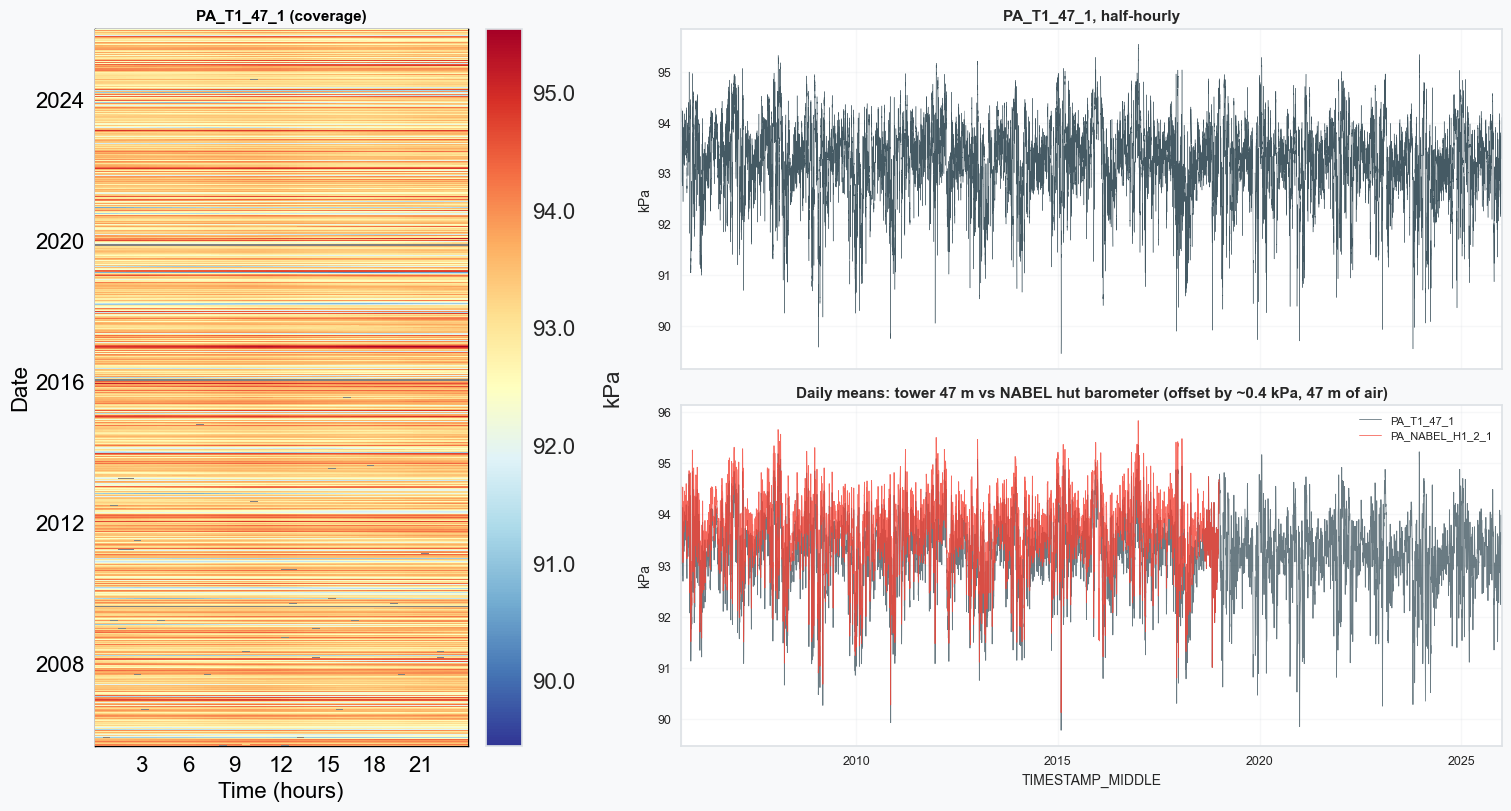

In [12]:
fig = plt.figure(figsize=(15, 8), dpi=100, layout='constrained')
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2.2], figure=fig)
ax_hm = fig.add_subplot(gs[:, 0])
ax_ts = fig.add_subplot(gs[0, 1])
ax_ref = fig.add_subplot(gs[1, 1], sharex=ax_ts)

dv.plotting.HeatmapDateTime(series=pa_2005_2025[TARGET]).plot(
    ax=ax_hm, cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=f'{TARGET} (coverage)', title_fontsize=11))

pa_2005_2025[TARGET].plot(ax=ax_ts, lw=0.3, color='#455A64')
ax_ts.set_ylabel('kPa')
ax_ts.set_title(f'{TARGET}, half-hourly', fontsize=11)

pa_2005_2025[[TARGET, REFERENCE]].resample('1D').mean().plot(
    ax=ax_ref, lw=0.6, color=['#455A64', '#F44336'], alpha=.8)
ax_ref.set_ylabel('kPa')
ax_ref.set_title('Daily means: tower 47 m vs NABEL hut barometer '
                 '(offset by ~0.4 kPa, 47 m of air)', fontsize=11)
ax_ref.legend(fontsize=8)

***

## ✴️ Corrections

### The reference series, and why they make these diagnostics possible

Two independent barometers are available for the corrections, and neither is on the tower logger —
which is exactly what is needed to judge a tower-logger fault.

`PA_NABEL_H1_2_1` sits at the hut, 2 m, on the **NABEL** acquisition system. It covers 2004-2018,
which includes all of 2012, so it is the reference for the 2012 diagnostics below. The tower sensor
reads a near-constant amount lower than the hut sensor, because it is 47 m higher; the offset is
computed from the data rather than assumed, and the value it lands on is the sanity check: 47 m of
air at this density is about 0.53 kPa. Subtracting that offset turns NABEL into a **predicted tower
pressure**, and the residual is then a sensitive fault detector — over an undisturbed period the two
agree to a few hundredths of a kPa.

NABEL **ends in 2018**. **MeteoSwiss Lägern** (2.5 km, 845 m) covers the whole 2004-2025 record and
is brought in further below as a second independent reference, so the years after 2018 can be
checked too — which NABEL alone cannot do.

In [13]:
OFFSET = float((pa_2005_2025[TARGET] - pa_2005_2025[REFERENCE]).median())
reference = pa_2005_2025[REFERENCE] + OFFSET   # NABEL expressed as expected tower pressure

print(f"median(tower - NABEL) = {OFFSET:+.4f} kPa")
print("  hydrostatic expectation for 47 m of air at ~93 kPa: about -0.53 kPa")

_res = (pa_2005_2025[TARGET] - reference).abs()
_quiet = _res.loc['2012-06-01':'2012-07-25']
BASELINE_P999 = float(_quiet.quantile(0.999))
print(f"\nundisturbed agreement (1 Jun - 25 Jul 2012): median {float(_quiet.median()):.4f} kPa, "
      f"p99 {float(_quiet.quantile(0.99)):.4f}, p99.9 {BASELINE_P999:.4f}")
print(f"whole-record median |residual|: {float(_res.median()):.4f} kPa")

median(tower - NABEL) = -0.3974 kPa
  hydrostatic expectation for 47 m of air at ~93 kPa: about -0.53 kPa

undisturbed agreement (1 Jun - 25 Jul 2012): median 0.0417 kPa, p99 0.0926, p99.9 0.1355
whole-record median |residual|: 0.0349 kPa


### Timestamp shift in August 2012

**Info from fieldbook entry 17 Aug 2012:**
>   adjusted the logger date and time. On Servertime (Computer System Time) 17.08.2012 12:31.42 the loggertime was 16.08.2012 08:06:00. Synchronized time at 17.08.2012 11:40:00 servertime. The logger data aquisition on the moxa embedded was restarted

This is a clock error of the logger, so it affects every variable that logger recorded. `PA_T1_47_1`
is on that logger (tower 1, 47 m, same acquisition system as `SW_IN_T1_47_1` and `TA_T1_47_1`), so
the same `+15.5 h` correction as in notebooks `01`-`03` is applied.

::: {.callout-important title="Why the lag diagnostic works for pressure after all"}
The obvious objection is that the per-day best-alignment lag search used in `01`-`03` relies on a
strong **diurnal** cycle, and pressure has almost none — the semidiurnal tide is ~1-2 hPa against
synoptic swings of tens of hPa. That objection is right about the diurnal cycle and wrong about the
conclusion.

The signal here is **synoptic, not diurnal**. Pressure wanders by 1-3 kPa over a few days and
decorrelates over roughly that timescale, so shifting the series by 15.5 h against an *independent
barometer* produces a large residual. What makes it work is having `PA_NABEL_H1_2_1` as a reference
that is not on the faulty logger; without a second barometer the test would indeed be underpowered.

The numbers below confirm it directly, and the confirmation is not subtle: over an undisturbed week
the two barometers agree to 0.03 kPa, and on the shifted days the zero-lag error is 10-20x that.

| date | best lag | RMSE at best lag | RMSE at zero lag |
|---|---|---|---|
| Jun 2012 (baseline) | 0 | 0.03 | 0.03 |
| 2012-07-27 | -1.0 h | 0.057 | 0.063 |
| 2012-07-29 | +1.0 h | 0.031 | 0.043 |
| 2012-07-30 | +5.0 h | 0.085 | 0.168 |
| 2012-07-31 | +29.0 h | 0.086 | 0.341 |
| 2012-08-06 | -31.5 h | 0.137 | 0.653 |
| 2012-08-07 | -35.5 h | 0.066 | 0.945 |
| **2012-08-11** | **+14.0 h** | **0.026** | 0.324 |
| **2012-08-15** | **+15.5 h** | **0.072** | 0.539 |
| **2012-08-16** | **+15.5 h** | **0.046** | 0.217 |
| 2012-08-18 | (alias) | 0.015 | 0.068 |

(RMSE in kPa, against the NABEL barometer. Lags searched over +/-48 h in 30 min steps.)

- **15-16 August** lock onto exactly `+15.5 h`, the same offset found in `SW_IN` and `TA`. That is
  the logger clock.
- **30 July to 9 August** never recovers at any lag, so it is not a clock problem — see the next
  section.
- Large apparent lags of 24-48 h are aliases: pressure is autocorrelated over days, so shifting by
  about a day partially realigns it. They are ignored.
:::

Notebooks `01`-`03` validate this correction with heatmaps, where the check is that the warm/bright
band returns to midday. **That check does not exist for pressure**, which has no diurnal band to
move. The validation used here instead is the residual against the NABEL barometer, before and
after: if the shift is right, the error collapses to the undisturbed baseline.

In [14]:
ISSUE_START = '2012-08-09 00:00'
ISSUE_END = '2012-08-17 00:00'
SHIFT_HOURS = 15.5

_df = pa_2005_2025.copy()
_before = _df[TARGET].copy()   # kept for the before/after comparison below

# Take the mis-stamped block and move it onto the correct time axis.
_series_shifted = _df.loc[ISSUE_START:ISSUE_END, TARGET].dropna()
_series_shifted.index = _series_shifted.index + pd.Timedelta(hours=SHIFT_HOURS)

# Clear everything between the start of the issue and the last shifted timestamp, then write the
# corrected values back. Same procedure as notebooks 01-03.
_df.loc[ISSUE_START:_series_shifted.index[-1], TARGET] = np.nan
_df.loc[_series_shifted.index, TARGET] = _series_shifted

print(f"shifted {len(_series_shifted):,} records by +{SHIFT_HOURS} h")
print(f"last shifted timestamp (corrected axis): {_series_shifted.index[-1]}")

# Validation: daily RMSE against the NABEL barometer, before vs after.
_rows = []
for _day in pd.date_range('2012-08-09', '2012-08-18', freq='D'):
    _d = _day.strftime('%Y-%m-%d')

    def _rmse(series):
        _x, _y = series.loc[_d], reference.loc[_d]
        _ok = _x.notna() & _y.notna()
        return float(np.sqrt(((_x[_ok] - _y[_ok]) ** 2).mean())) if _ok.sum() >= 12 else np.nan

    _rows.append((_d, _rmse(_before), _rmse(_df[TARGET])))

_check = pd.DataFrame(_rows, columns=['date', 'RMSE_before_kPa', 'RMSE_after_kPa']).set_index('date')
_check['improvement'] = (_check.RMSE_before_kPa - _check.RMSE_after_kPa).round(3)
display(_check.round(3))
print("Undisturbed agreement is about 0.04 kPa, so 'after' values near 0.05 kPa mean the "
      "correction landed.")

shifted 376 records by +15.5 h
last shifted timestamp (corrected axis): 2012-08-17 11:15:00


,RMSE_before_kPa,RMSE_after_kPa,improvement
date,,,
2012-08-09,0.066,0.079,-0.013
2012-08-10,0.136,0.053,0.083
2012-08-11,0.324,0.046,0.278
2012-08-12,0.091,0.053,0.038
2012-08-13,0.103,0.061,0.042
2012-08-14,0.070,0.066,0.005
2012-08-15,0.539,0.072,0.467
2012-08-16,0.217,0.046,0.171
2012-08-17,0.073,0.060,0.012


Undisturbed agreement is about 0.04 kPa, so 'after' values near 0.05 kPa mean the correction landed.


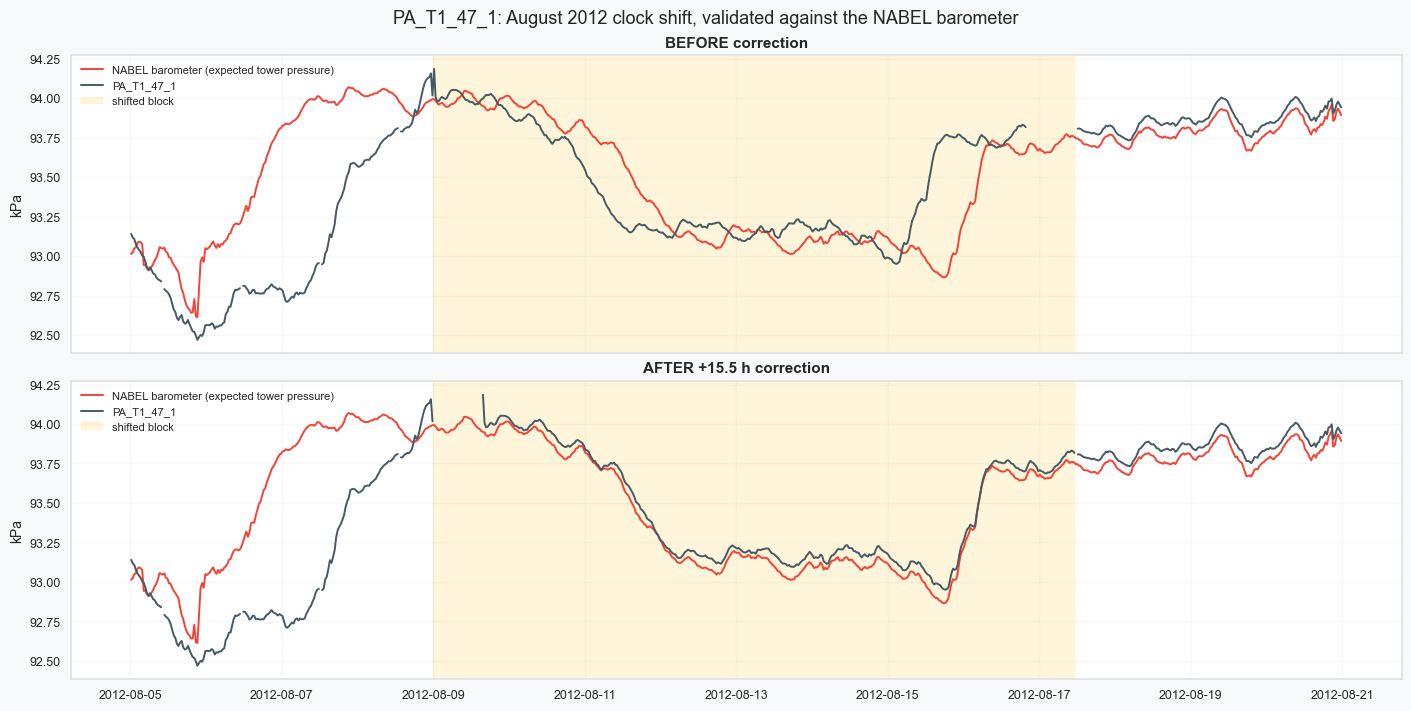

In [15]:
# Visual check: tower vs reference around the shift, before and after.
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained',
                        sharex=True, sharey=True)
fig.suptitle(f'{TARGET}: August 2012 clock shift, validated against the NABEL barometer',
             fontsize=13)
_win = slice('2012-08-05', '2012-08-20')

for _ax, _series, _title in [(axs[0], _before, 'BEFORE correction'),
                             (axs[1], _df[TARGET], f'AFTER +{SHIFT_HOURS} h correction')]:
    _ax.plot(reference.loc[_win].index, reference.loc[_win].values,
             color='#F44336', lw=1.4, label='NABEL barometer (expected tower pressure)')
    _ax.plot(_series.loc[_win].index, _series.loc[_win].values,
             color='#455A64', lw=1.4, label=TARGET)
    _ax.axvspan(pd.Timestamp('2012-08-09'), pd.Timestamp('2012-08-17 11:15'),
                color='#FFC107', alpha=.15, label='shifted block')
    _ax.set_title(_title, fontsize=11)
    _ax.set_ylabel('kPa')
    _ax.legend(fontsize=8, loc='upper left')

In [16]:
pa_2005_2025 = _df.copy()
pa_2005_2025

,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


### Damaged periods in 2012

Two periods cannot be repaired by a shift, and are removed. They are the same two faults that
notebooks `01`-`03` remove, but **the windows here are derived from `PA`'s own evidence** rather
than copied, and they differ from the shared ones.

The evidence is the residual against the NABEL barometer, on the **corrected** time axis, in
half-day blocks. Undisturbed, |residual| stays near 0.04 kPa (p99.9 = 0.136 kPa over 1 Jun - 25 Jul
2012). Blocks marked `*` exceed that:

| block (corrected axis) | mean abs. residual | verdict |
|---|---|---|
| 2012-07-29 all day | 0.039 / 0.045 | clean |
| 2012-07-30 00:00-12:00 | 0.035 | clean |
| **2012-07-30 12:00-24:00** | **0.177** | * fault begins |
| 2012-07-31 00:00-12:00 | 0.383 | * |
| 2012-08-07 00:00-12:00 | 1.119 | * worst |
| 2012-08-09 12:00-24:00 | 0.065 (max 0.236) | * last bad block |
| **2012-08-10 00:00-12:00** | **0.036** | clean, fault over |
| 2012-10-28, 2012-10-29 | 0.006 - 0.017 | **clean** (best days in the record) |
| **2012-10-30 00:00-12:00** | **0.198** | * second fault begins |
| 2012-11-01 00:00-12:00 | 2.365 | * worst |
| 2012-11-09 00:00-12:00 | 0.115 | * last bad block |
| **2012-11-09 12:00-24:00** | **0.046** | clean, fault over |

The fieldbook gives the causes, and they are the same ones documented at length in notebooks `01`
and `02`:

> **09.08.2012** Fixed the power problem on the tower: replaced battery and replaced some fuses
> (there were many falsely placed or broken) and replaced the whole power supply
>
> **01.11.2012** Checked Forestfloor and Hut for broken sensors due to fallen trees and big branches
>
> **06.11.2012** checked all sensor cables. especialy the cables at the forest floor are sometimes
> strongly stressed. tried to unstress the cables

`PA` recovers on 10 August, the day after the power supply was replaced, and on 9 November, three
days after the cable work. The fault signature is a **level error** — the sensor keeps reporting a
full 48 records a day, but biased by up to +2.4 kPa — not a dropout and not a phase error, which is
what a mis-powered barometer looks like.

**Where these windows differ from `01`-`03`, and why:**

| | notebooks 01-03 | here | reason |
|---|---|---|---|
| window 1 | 07-29 00:00 -> 08-10 15:30 | 07-30 12:00 -> 08-10 00:00 | `PA` is still clean through 30 July midday |
| window 2 | 08-17 15:30 -> 08-18 00:00 | *(none)* | `PA` is clean on 17-18 Aug (0.04-0.08 kPa) |
| window 3 | 10-28 00:00 -> 11-10 00:00 | 10-30 00:00 -> 11-09 12:00 | 28-29 Oct are `PA`'s two **best** days |

Notebook `02` widened `TA`'s third window to 28 October to match `SW_IN` and the shared cause,
knowingly discarding one good day. That trade is not made here: with 969 records removed instead of
1,209, `PA` keeps 240 half-hours (5 days) of measurements that its own independent reference shows
to be sound. Because this product is not gap-filled, a removed record is a permanent hole rather
than a modelled value, which makes the case for keeping demonstrably good data stronger.

**Consequence to be aware of:** the four METEO products no longer exclude byte-identical periods.
Anything downstream that assumes they do should use each product's own missingness.

In [17]:
# Derived from PA's own residual against the NABEL barometer (see the table above), NOT copied
# from notebooks 01-03. Windows are on the CORRECTED time axis, i.e. after the +15.5 h shift.
BAD_WINDOWS_2012 = [
    ('2012-07-30 12:00', '2012-08-10 00:00'),  # tower power supply failure (fieldbook 09.08.2012)
    ('2012-10-30 00:00', '2012-11-09 12:00'),  # storm damage, stressed cables (fieldbook 01./06.11.2012)
]

_before_n = int(pa_2005_2025[TARGET].notna().sum())
for _start, _end in BAD_WINDOWS_2012:
    pa_2005_2025.loc[_start:_end, TARGET] = np.nan
_removed = _before_n - int(pa_2005_2025[TARGET].notna().sum())
print(f"Removed {_removed:,} degraded records from {TARGET} (left as gaps, nothing is filled).")

# Verify: nothing above the undisturbed baseline should survive in 2012.
_res_2012 = (pa_2005_2025[TARGET] - reference).abs().loc['2012'].dropna()
_exceed = _res_2012[_res_2012 > BASELINE_P999]
print(f"\n2012 after removal: median |residual| {float(_res_2012.median()):.4f} kPa, "
      f"max {float(_res_2012.max()):.4f} kPa")
print(f"records still above the undisturbed p99.9 ({BASELINE_P999:.4f} kPa): {len(_exceed)}")
if len(_exceed):
    display(_exceed.groupby(_exceed.index.normalize()).agg(['count', 'max']))
    print("(a handful of isolated records in undisturbed months is ordinary tail noise, "
          "not a missed fault period)")

Removed 969 degraded records from PA_T1_47_1 (left as gaps, nothing is filled).

2012 after removal: median |residual| 0.0322 kPa, max 0.1761 kPa
records still above the undisturbed p99.9 (0.1355 kPa): 3


,count,max
TIMESTAMP_MIDDLE,,
2012-06-07,1,0.138509
2012-06-21,1,0.176122
2012-06-30,1,0.174126


(a handful of isolated records in undisturbed months is ordinary tail noise, not a missed fault period)


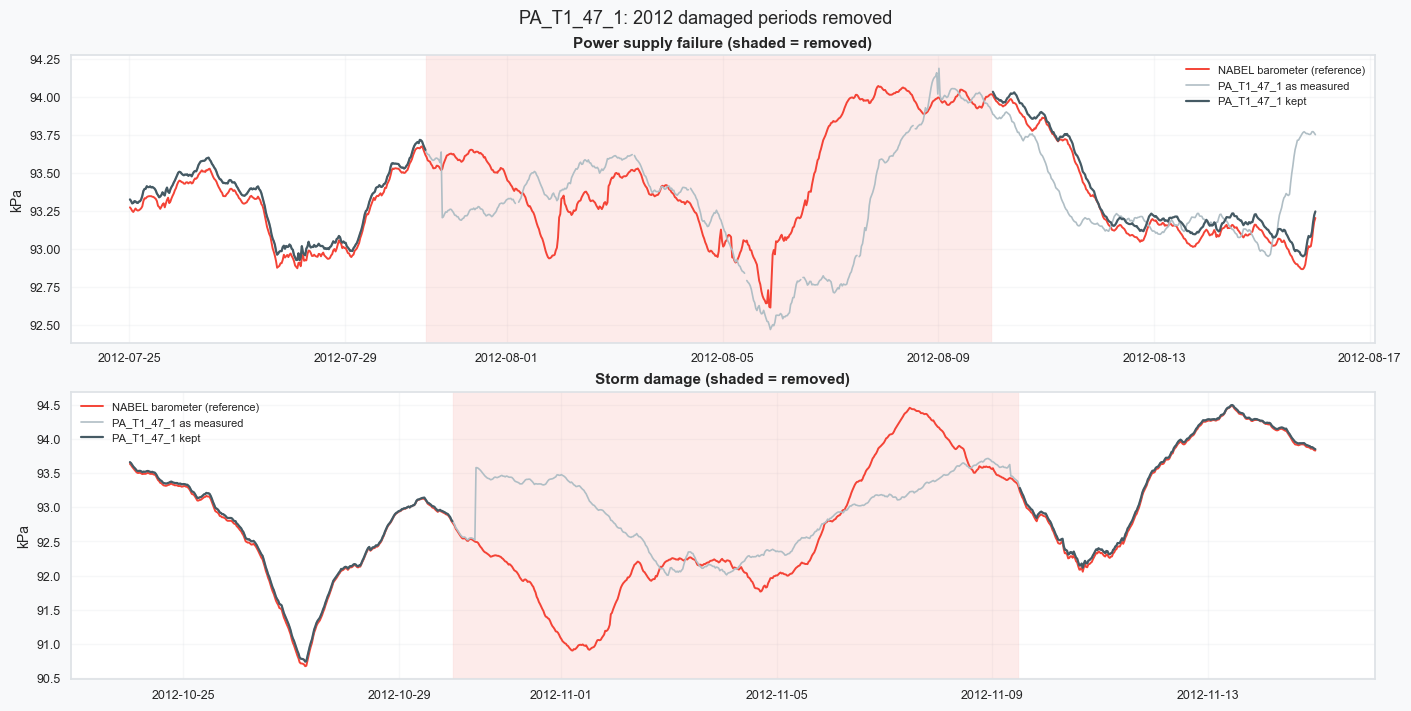

In [18]:
# The two fault periods, before/after, against the reference.
fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained')
fig.suptitle(f'{TARGET}: 2012 damaged periods removed', fontsize=13)

for _ax, (_lo, _hi, _label) in zip(axs, [('2012-07-25', '2012-08-15', 'Power supply failure'),
                                         ('2012-10-24', '2012-11-14', 'Storm damage')]):
    _w = slice(_lo, _hi)
    _ax.plot(reference.loc[_w].index, reference.loc[_w].values,
             color='#F44336', lw=1.4, label='NABEL barometer (reference)')
    _ax.plot(_before.loc[_w].index, _before.loc[_w].values,
             color='#B0BEC5', lw=1.2, label=f'{TARGET} as measured')
    _ax.plot(pa_2005_2025[TARGET].loc[_w].index, pa_2005_2025[TARGET].loc[_w].values,
             color='#455A64', lw=1.6, label=f'{TARGET} kept')
    for _s, _e in BAD_WINDOWS_2012:
        if pd.Timestamp(_s) <= pd.Timestamp(_hi) and pd.Timestamp(_e) >= pd.Timestamp(_lo):
            _ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color='#F44336', alpha=.10)
    _ax.set_title(f'{_label} (shaded = removed)', fontsize=11)
    _ax.set_ylabel('kPa')
    _ax.legend(fontsize=8, loc='best')

::: {.callout-note title="No zero-offset correction here"}
Notebooks `01` and `03` remove a nighttime zero-offset from `SW_IN` and `PPFD_IN`. That correction
exists because radiation has a known true value at night, namely zero, so any nonzero nighttime
reading is measurable sensor offset. Pressure has no such reference value at any time of day, so
there is no equivalent step and none is applied.

The related trap from notebook `03` — a correction that writes into gaps and thereby relabels fills
as measurements — **cannot occur in this notebook**: no correction here writes a value into a
missing record. The clock shift moves existing records, and the 2012 windows only ever set values to
`NaN`. Gap counts are therefore honest at every stage, which the export checks below confirm.
:::

### 🌍 MeteoSwiss Lägern: an independent check across the whole record

The NABEL barometer used above **stops in 2018**, so on its own it cannot confirm the second half of
the record. MeteoSwiss Lägern (2.5 km away at 845 m) measures station pressure over the full
2004-2025 span and closes that gap.

Pressure is strongly spatially coherent: once a constant altitude offset is removed, the tower and
Lägern correlate ~0.99. Lägern is stored in `hPa`, so it is divided by 10 to `kPa`. It sits ~155 m
above the tower barometer (~690 m) and therefore reads a near-constant amount **lower**; that offset
is **fitted from the overlap** (mean of `tower - Lägern` where both are present), not assumed, and
added to Lägern so the two are directly comparable.

Like NABEL, Lägern is a **diagnostic reference only** — never exported, and it never changes a tower
value. Two checks follow: the alignment guard (as in notebooks `01`-`03`) proves the
`TIMESTAMP_END -> TIMESTAMP_MID` conversion, and the residual before and after 2018 shows the tower
and Lägern stay in agreement, i.e. no shift or fault slipped through after NABEL ended.

In [19]:
pa_lae = pd.read_parquet(REFPATH)[[REFCOL]].copy()
pa_lae.index = pa_lae.index - pd.Timedelta(minutes=15)  # TIMESTAMP_END -> TIMESTAMP_MID
pa_lae.index.name = pa_2005_2025.index.name
pa_lae = (pa_lae[REFCOL] / 10.0).reindex(pa_2005_2025.index)  # hPa -> kPa, onto the product index

# Hydrostatic offset, fitted from the overlap rather than guessed: Laegern (845 m) reads lower than
# the tower barometer (~690 m). Add it to Laegern so both sit on the tower's pressure level.
_both = pd.concat([pa_2005_2025[TARGET].rename('tower'), pa_lae.rename('lae')], axis=1).dropna()
LAE_OFFSET = float((_both['tower'] - _both['lae']).mean())
lae_adjusted = pa_lae + LAE_OFFSET
print(f"fitted tower - Laegern offset: {LAE_OFFSET:+.4f} kPa "
      f"(mean over {len(_both):,} overlapping records; Laegern reads lower, sitting ~155 m higher)")

# Alignment guard (as in notebooks 01-03): correlate the measured tower PA against Laegern-adjusted
# at -1/0/+1 half-hour offsets. Offset 0 must win, which proves the TIMESTAMP_MID conversion.
# Pressure is spatially coherent, so the correlation is ~0.99 and the zero-lag peak is clear.
_meas = pa_2005_2025[TARGET]
_scores = {}
for _off in (-1, 0, 1):
    _j = pd.concat([_meas.rename('t'), lae_adjusted.shift(_off).rename('r')], axis=1).dropna()
    _scores[_off] = _j['t'].corr(_j['r'])
    print(f"  offset {_off:+d} x 30min: corr {_scores[_off]:.5f}")
assert max(_scores, key=_scores.get) == 0, f"reference is mis-aligned: {_scores}"
print("OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.")

fitted tower - Laegern offset: +1.2798 kPa (mean over 352,075 overlapping records; Laegern reads lower, sitting ~155 m higher)
  offset -1 x 30min: corr 0.99033
  offset +0 x 30min: corr 0.99063
  offset +1 x 30min: corr 0.99018
OK: offset 0 wins, the TIMESTAMP_MID conversion is correct.


  2005-2018 (NABEL also present)   median +0.0678  std 0.0766 kPa  n=230,251
  2019-2025 (Laegern only)         median -0.1065  std 0.0424 kPa  n=121,824
A tight, stable residual in both halves means Laegern sees no undetected shift or fault after 2018 - the check NABEL alone could not provide.


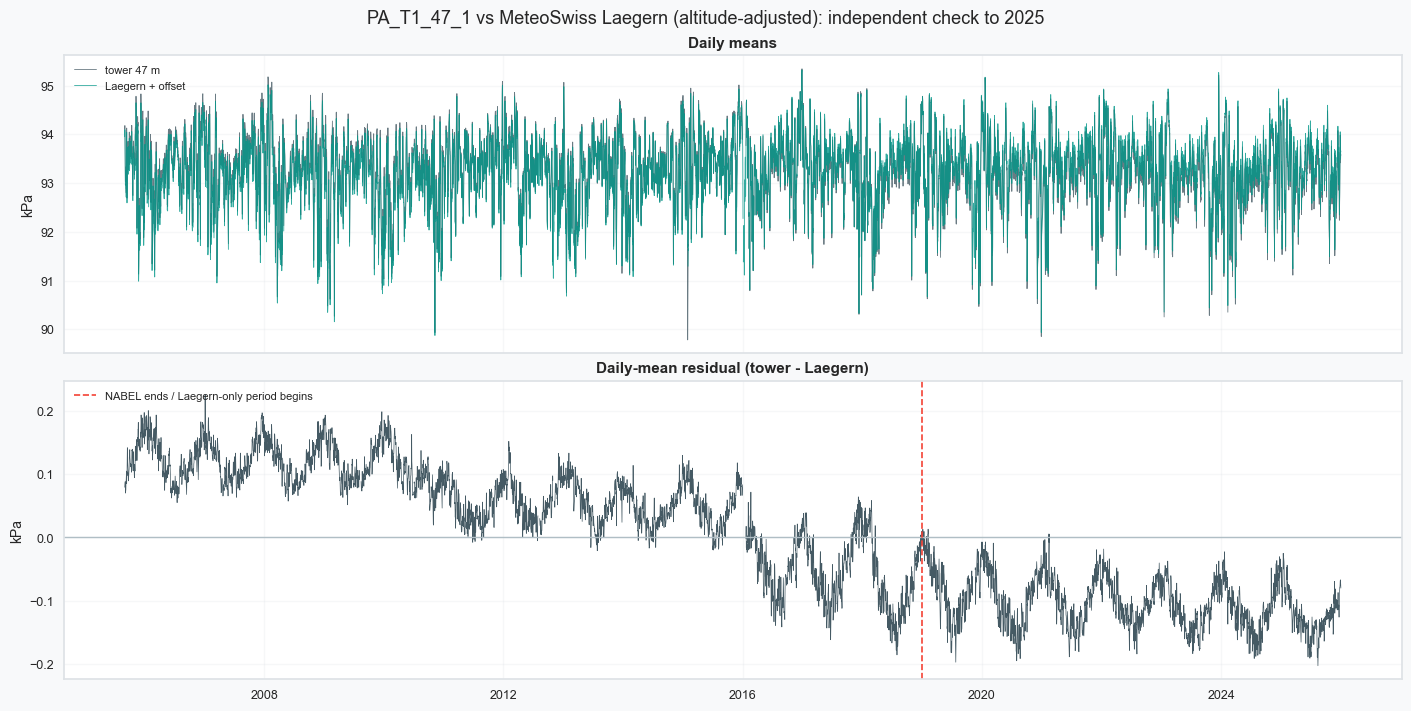

In [20]:
# The post-2018 payoff: NABEL has stopped, Laegern has not. If a timestamp shift or a level fault
# had gone undetected after 2018, the tower - Laegern residual would step or widen there. It does not.
_res_lae = (pa_2005_2025[TARGET] - lae_adjusted)
for _lbl, _sl in [('2005-2018 (NABEL also present)', slice(None, '2018-12-31')),
                  ('2019-2025 (Laegern only)', slice('2019-01-01', None))]:
    _r = _res_lae.loc[_sl].dropna()
    print(f"  {_lbl:<32} median {float(_r.median()):+.4f}  std {float(_r.std()):.4f} kPa  n={len(_r):,}")
print("A tight, stable residual in both halves means Laegern sees no undetected shift or fault after "
      "2018 - the check NABEL alone could not provide.")

fig, axs = plt.subplots(nrows=2, figsize=(14, 7), dpi=100, layout='constrained', sharex=True)
fig.suptitle(f'{TARGET} vs MeteoSwiss Laegern (altitude-adjusted): independent check to 2025',
             fontsize=13)
_daily = pd.DataFrame({'tower': pa_2005_2025[TARGET], 'lae': lae_adjusted}).resample('1D').mean()
axs[0].plot(_daily.index, _daily['tower'].values, lw=0.6, color='#455A64', alpha=.8, label='tower 47 m')
axs[0].plot(_daily.index, _daily['lae'].values, lw=0.6, color='#009688', alpha=.8, label='Laegern + offset')
axs[0].set_ylabel('kPa')
axs[0].set_title('Daily means', fontsize=11)
axs[0].legend(fontsize=8, loc='upper left')

_res_daily = _res_lae.resample('1D').mean()
axs[1].plot(_res_daily.index, _res_daily.values, lw=0.5, color='#455A64')
axs[1].axhline(0, color='#B0BEC5', lw=1)
axs[1].axvline(pd.Timestamp('2019-01-01'), color='#F44336', ls='--', lw=1.2,
               label='NABEL ends / Laegern-only period begins')
axs[1].set_ylabel('kPa')
axs[1].set_title('Daily-mean residual (tower - Laegern)', fontsize=11)
axs[1].legend(fontsize=8, loc='upper left')

### Dataframe

In [21]:
display(pa_2005_2025)
pa_2005_2025.describe()

,PA_T1_47_1,PA_NABEL_H1_2_1
TIMESTAMP_MIDDLE,,
2005-09-02 00:15:00,NaN,94.184167
2005-09-02 00:45:00,NaN,94.197500
2005-09-02 01:15:00,NaN,94.210833
2005-09-02 01:45:00,NaN,94.227500
2005-09-02 02:15:00,NaN,94.220833
...,...,...
2025-12-31 21:45:00,93.435334,NaN
2025-12-31 22:15:00,93.422110,NaN
2025-12-31 22:45:00,93.404179,NaN


,PA_T1_47_1,PA_NABEL_H1_2_1
count,352438.000000,233168.000000
mean,93.231834,93.654531
std,0.738882,0.744573
min,89.446007,89.786333
25%,92.849998,93.256333
50%,93.306183,93.729333
75%,93.697846,94.135004
max,95.543335,96.029917


***

## 🚫 No gap-filling here

Notebooks `01`-`03` produce gap-filled products. This one does not, and the series is exported as
measured.

The measured record is **99.15% complete** before the 2012 removals and 98.88% after them, against
91.5% / 96.0% / 95.7% for `SW_IN` / `TA` / `PPFD_IN`. Of 420 gaps from the start of the record, 405
are one hour or shorter.

Pressure would in fact be the easiest of these variables to fill — it is smooth, strongly
autocorrelated, and a nearby barometer tracks it closely throughout (NABEL to ~0.04 kPa until
2018, MeteoSwiss Lägern to within ~0.1 kPa across the whole record). That is
precisely why the decision matters and is recorded here rather than assumed: a filled `PA` would
look almost indistinguishable from a measured one, so downstream users could not tell them apart
without a flag, and this product deliberately ships only measurements.

Consequences for anything consuming this file:

- `PA_T1_47_1` **contains `NaN`**. Code that assumes a complete series will break or silently
  propagate `NaN`, so handle the gaps explicitly.
- There is **no `FLAG_..._ISFILLED` column**, because there is nothing to flag. Non-null means
  measured.
- If a complete series is needed later, fill it downstream where the fill can be flagged in that
  product's own terms.

***

## ➡️ Prepare dataframe for export

In [22]:
VALCOL = TARGET

export_df = pa_2005_2025[[VALCOL]].copy()   # the NABEL reference is diagnostic only, not exported
export_df

,PA_T1_47_1
TIMESTAMP_MIDDLE,
2005-09-02 00:15:00,NaN
2005-09-02 00:45:00,NaN
2005-09-02 01:15:00,NaN
2005-09-02 01:45:00,NaN
2005-09-02 02:15:00,NaN
...,...
2025-12-31 21:45:00,93.435334
2025-12-31 22:15:00,93.422110
2025-12-31 22:45:00,93.404179


Sanity check. Unlike `01`-`03` the series is **not** expected to be complete, so the check is that
the gaps are the ones we know about, and that every value present is physically plausible pressure
in kPa. The range check is the last line of defence against a unit error reaching the file.

In [23]:
_lo, _hi = PA_PLAUSIBLE_KPA

print(f"Records:          {len(export_df):,}")
print(f"Measured:         {int(export_df[VALCOL].notna().sum()):,} "
      f"({100 * export_df[VALCOL].notna().mean():.2f}%)")
print(f"Missing (NaN):    {int(export_df[VALCOL].isnull().sum()):,} "
      f"({100 * export_df[VALCOL].isna().mean():.2f}%)")
print(f"Duplicate index:  {int(export_df.index.duplicated().sum())}")
print(f"Index gaps:       "
      f"{int((export_df.index.to_series().diff().dropna() != pd.Timedelta('30min')).sum())}")
print(f"Index:            {export_df.index[0]} -> {export_df.index[-1]}")
print(f"Min / max:        {export_df[VALCOL].min():.3f} / {export_df[VALCOL].max():.3f} kPa")

# Hard guards: every one of these would indicate a serious problem.
assert export_df.index.duplicated().sum() == 0, "duplicate timestamps"
assert (export_df.index.to_series().diff().dropna() == pd.Timedelta('30min')).all(), \
    "index not continuous 30MIN"
assert export_df[VALCOL].min() >= _lo and export_df[VALCOL].max() <= _hi, \
    f"values outside {_lo}-{_hi} kPa - possible unit error"
assert export_df[VALCOL].notna().any(), "no data at all"
print("\nAll checks passed.")

export_df.describe()

Records:          356,448
Measured:         352,438 (98.88%)
Missing (NaN):    4,010 (1.12%)
Duplicate index:  0
Index gaps:       0
Index:            2005-09-02 00:15:00 -> 2025-12-31 23:45:00
Min / max:        89.446 / 95.543 kPa

All checks passed.


,PA_T1_47_1
count,352438.000000
mean,93.231834
std,0.738882
min,89.446007
25%,92.849998
50%,93.306183
75%,93.697846
max,95.543335


### Per-year statistics

For this variable the per-year **median** is the check that unit harmonisation worked: every year
from 2005 to 2025 has to sit at ~93 kPa, with no step at the 2021/2022 source boundary. A year
reading ~93,000 or ~930 would mean a source slipped through unconverted.

`coverage_%` shows where the real gaps are: 2012 is the year of the removed fault periods, and 2016
and 2019 have sensor outages that are left as gaps. 2005 is a partial year by construction, since
the record starts on 2 September.

In [24]:
_yr = export_df[VALCOL].groupby(export_df.index.year).agg(['count', 'median', 'min', 'max', 'std'])
_yr['possible'] = export_df[VALCOL].groupby(export_df.index.year).size()
_yr['coverage_%'] = (100 * _yr['count'] / _yr['possible']).round(2)
_yr['source'] = np.where(_yr.index <= 2021, 'mst', 'diive')
display(_yr.round(3))

# The harmonisation check, stated as an assertion rather than left to the eye.
_med = _yr['median']
assert ((_med > 85) & (_med < 100)).all(), \
    f"a yearly median is outside 85-100 kPa: {_med[(_med <= 85) | (_med >= 100)].to_dict()}"
print(f"All yearly medians between {_med.min():.3f} and {_med.max():.3f} kPa "
      f"(spread {_med.max() - _med.min():.3f} kPa) - no unit break survives.")

_step = abs(float(_med.loc[2022]) - float(_med.loc[2021]))
print(f"step across the 2021/2022 source boundary: {_step:.3f} kPa "
      f"(interannual spread is {float(_med.std()):.3f} kPa, so this is ordinary weather)")

,count,median,min,max,std,possible,coverage_%,source
TIMESTAMP_MIDDLE,,,,,,,,
2005,5774,93.584,91.040,94.995,0.771,5808,99.41,mst
2006,17445,93.405,90.990,94.954,0.679,17520,99.57,mst
2007,17461,93.420,90.691,95.066,0.674,17520,99.66,mst
2008,17492,93.293,90.244,95.323,0.824,17568,99.57,mst
2009,17000,93.309,89.574,94.611,0.798,17520,97.03,mst
2010,17323,93.096,89.740,94.513,0.775,17520,98.88,mst
2011,17488,93.460,90.045,95.169,0.611,17520,99.82,mst
2012,16539,93.377,90.740,94.952,0.689,17568,94.14,mst
2013,17447,93.328,90.524,95.210,0.797,17520,99.58,mst


All yearly medians between 93.096 and 93.584 kPa (spread 0.488 kPa) - no unit break survives.
step across the 2021/2022 source boundary: 0.065 kPa (interannual spread is 0.127 kPa, so this is ordinary weather)


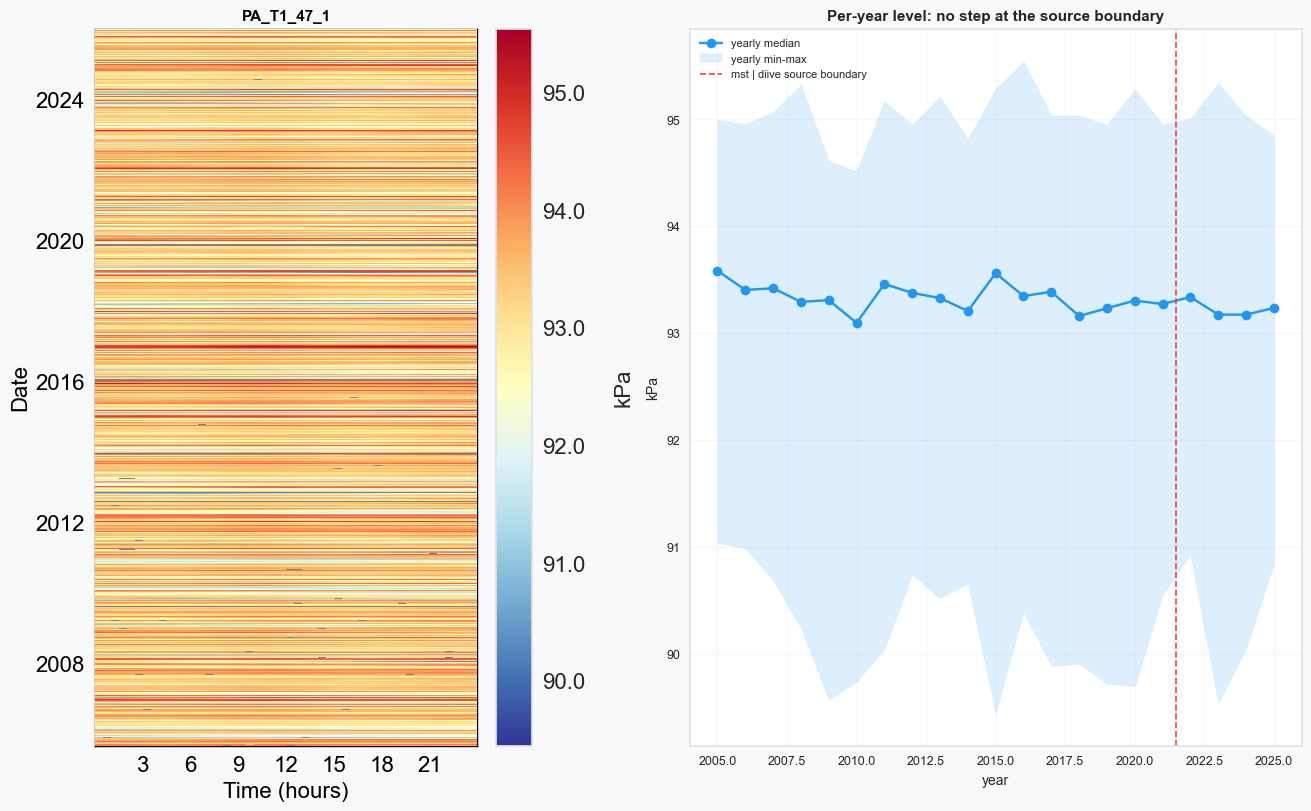

In [25]:
fig, axs = plt.subplots(ncols=2, figsize=(13, 8), dpi=100, layout='constrained',
                        width_ratios=[1, 1.6])
dv.plotting.HeatmapDateTime(series=export_df[VALCOL]).plot(
    ax=axs[0], cb_digits_after_comma=1, zlabel='kPa',
    format_style=dv.plotting.FormatStyle(title=VALCOL, title_fontsize=11))

_yr['median'].plot(ax=axs[1], marker='o', color='#2196F3', label='yearly median')
axs[1].fill_between(_yr.index, _yr['min'], _yr['max'], color='#2196F3', alpha=.15,
                    label='yearly min-max')
axs[1].axvline(2021.5, color='#F44336', ls='--', lw=1.2, label='mst | diive source boundary')
axs[1].set_ylabel('kPa')
axs[1].set_xlabel('year')
axs[1].set_title('Per-year level: no step at the source boundary', fontsize=11)
axs[1].legend(fontsize=8)

***

## 💾 Save to file

In [26]:
filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
export_df.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\05_METEO_PA_2005-2025.parquet (0.042 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\05_METEO_PA_2005-2025.parquet


### Verify the written file

Reading the parquet back and checking it directly, rather than trusting the in-memory frame.

In [27]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns:   {list(_written.columns)}")
print(f"index:     {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)")
print(f"measured:  {int(_written[VALCOL].notna().sum()):,} "
      f"({100 * _written[VALCOL].notna().mean():.2f}%)")
print(f"median:    {float(_written[VALCOL].median()):.3f} kPa")
print(f"min / max: {float(_written[VALCOL].min()):.3f} / {float(_written[VALCOL].max()):.3f} kPa")

assert list(_written.columns) == [VALCOL], "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written[VALCOL].notna().sum() == export_df[VALCOL].notna().sum(), \
    "measured count changed on write"
assert 85 < float(_written[VALCOL].median()) < 100, "median outside plausible kPa range"
print("\nWritten file verified.")

display(_written[VALCOL].groupby(_written.index.year).median().round(3)
        .rename('yearly median (kPa)'))

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\05_METEO_PA_2005-2025.parquet (0.012 seconds).

columns:   ['PA_T1_47_1']
index:     2005-09-02 00:15:00 -> 2025-12-31 23:45:00  (356,448 records)
measured:  352,438 (98.88%)
median:    93.306 kPa
min / max: 89.446 / 95.543 kPa

Written file verified.


TIMESTAMP_MIDDLE
2005    93.584
2006    93.405
2007    93.420
2008    93.293
2009    93.309
2010    93.096
2011    93.460
2012    93.377
2013    93.328
2014    93.207
2015    93.561
2016    93.347
2017    93.387
2018    93.160
2019    93.234
2020    93.305
2021    93.272
2022    93.338
2023    93.174
2024    93.173
2025    93.236
Name: yearly median (kPa), dtype: float64

***

## End of notebook.

In [28]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-21 00:55:56
Finished: 2026-07-21 00:57:14
Runtime:  00:01:18 (hh:mm:ss)
